In [1]:
# 목적: 추가 리스크 신호 수집 — Put/Call Ratio + 섹터 상관관계

import pandas as pd
import numpy as np
import yfinance as yf
import os
import matplotlib.pyplot as plt

data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

# 저장된 주가 데이터 로드
prices = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
returns = prices.pct_change().dropna()

print("로드 완료")
print(f"주가 데이터: {prices.shape}")

로드 완료
주가 데이터: (2138, 5)


In [2]:
# ^PCCE 대신 ^CPC (CBOE Total Put/Call Ratio) 사용
pcr = yf.download("^CPC", start="2018-01-01", auto_adjust=True, progress=False)["Close"]
pcr.name = "PCR"
pcr = pcr.dropna()

if pcr.empty:
    # 그것도 안되면 ^CPCE 시도
    pcr = yf.download("^CPCE", start="2018-01-01", auto_adjust=True, progress=False)["Close"]
    pcr.name = "PCR"
    pcr = pcr.dropna()

print(f"Put/Call Ratio 데이터: {pcr.shape}")
if not pcr.empty:
    print(f"기간: {pcr.index[0].date()} ~ {pcr.index[-1].date()}")
    print(f"현재값: {pcr.iloc[-1]:.3f}")
else:
    print("데이터 없음 — 대안 사용 필요")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^CPC"}}}
$^CPC: possibly delisted; no timezone found

1 Failed download:
['^CPC']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^CPCE"}}}
$^CPCE: possibly delisted; no timezone found

1 Failed download:
['^CPCE']: possibly delisted; no timezone found


Put/Call Ratio 데이터: (0, 1)
데이터 없음 — 대안 사용 필요


In [3]:
# Put/Call Ratio 대신 섹터 ETF로 상관관계 분석
# 주요 섹터 ETF
SECTOR_ETFS = {
    "Tech":       "XLK",
    "Finance":    "XLF", 
    "Healthcare": "XLV",
    "Energy":     "XLE",
    "Consumer":   "XLY",
    "Utilities":  "XLU",
    "Semiconductor": "SOXX"
}

# 섹터 ETF 데이터 수집
sector_df = yf.download(
    list(SECTOR_ETFS.values()),
    start="2018-01-01",
    auto_adjust=True,
    progress=False
)["Close"]
sector_df.columns = list(SECTOR_ETFS.keys())
sector_df = sector_df.dropna()
sector_returns = sector_df.pct_change().dropna()

print(f"섹터 데이터: {sector_df.shape}")
print(f"기간: {sector_df.index[0].date()} ~ {sector_df.index[-1].date()}")

섹터 데이터: (2138, 7)
기간: 2018-01-02 ~ 2026-07-07


In [4]:

# 섹터 간 상관관계 이상 감지
# 평소엔 섹터들이 독립적으로 움직이다가, 위기 때 갑자기 같이 떨어짐
# 이 "동조화 현상"을 조기에 감지하는 게 핵심

def calculate_correlation_risk(sector_returns, window=30):
    """
    30일 롤링 평균 상관관계 계산
    - 평균 상관관계가 높을수록 동조화 → 위기 신호
    """
    rolling_corr = []
    dates = []

    for i in range(window, len(sector_returns)):
        window_data = sector_returns.iloc[i-window:i]
        corr_matrix = window_data.corr()
        # 대각선 제외한 상관관계 평균
        mask = np.ones(corr_matrix.shape, dtype=bool)
        np.fill_diagonal(mask, False)
        avg_corr = corr_matrix.values[mask].mean()
        rolling_corr.append(avg_corr)
        dates.append(sector_returns.index[i])

    return pd.Series(rolling_corr, index=dates, name="avg_correlation")

corr_risk = calculate_correlation_risk(sector_returns)

print(f"상관관계 리스크 지표: {corr_risk.shape}")
print(f"\n통계:")
print(f"  평균: {corr_risk.mean():.3f}")
print(f"  최대: {corr_risk.max():.3f} (동조화 극대 — 위기)")
print(f"  최소: {corr_risk.min():.3f} (독립적 — 안정)")
print(f"\n현재값: {corr_risk.iloc[-1]:.3f}")
print(f"  → {'위험 (동조화)' if corr_risk.iloc[-1] > 0.7 else '안정 (독립적)'}")

상관관계 리스크 지표: (2107,)

통계:
  평균: 0.439
  최대: 0.926 (동조화 극대 — 위기)
  최소: 0.018 (독립적 — 안정)

현재값: 0.018
  → 안정 (독립적)


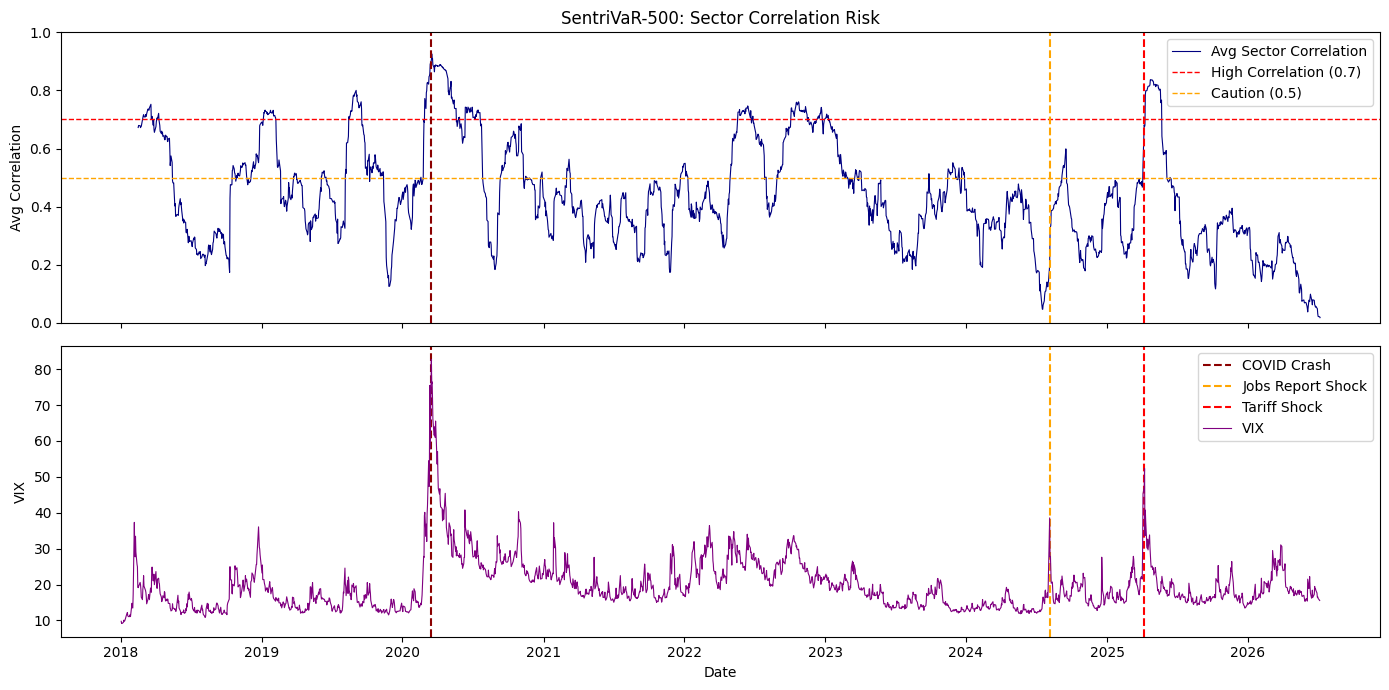

저장 완료: correlation_risk.png


In [5]:
# 시각화 — 상관관계 리스크 vs VIX
macro = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# 섹터 평균 상관관계
ax1.plot(corr_risk.index, corr_risk, color="navy", linewidth=0.8, label="Avg Sector Correlation")
ax1.axhline(0.7, color="red", linestyle="--", linewidth=1, label="High Correlation (0.7)")
ax1.axhline(0.5, color="orange", linestyle="--", linewidth=1, label="Caution (0.5)")
ax1.set_ylabel("Avg Correlation")
ax1.set_title("SentriVaR-500: Sector Correlation Risk")
ax1.set_ylim(0, 1)
ax1.legend(loc="upper right")

# 케이스 스터디 이벤트
for ax in [ax1, ax2]:
    ax.axvline(pd.Timestamp("2020-03-16"), color="darkred",
               linestyle="--", linewidth=1.5, label="COVID Crash")
    ax.axvline(pd.Timestamp("2024-08-05"), color="orange",
               linestyle="--", linewidth=1.5, label="Jobs Report Shock")
    ax.axvline(pd.Timestamp("2025-04-07"), color="red",
               linestyle="--", linewidth=1.5, label="Tariff Shock")

# VIX
ax2.plot(macro.index, macro["VIX"], color="purple", linewidth=0.8, label="VIX")
ax2.set_ylabel("VIX")
ax2.set_xlabel("Date")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{data_path}/correlation_risk.png", dpi=150)
plt.show()
print("저장 완료: correlation_risk.png")